In [1]:
# ============================================================
# PASO 1: Cargar dataset y validar estructura inicial
# ============================================================

import pandas as pd
import numpy as np

# Cargar archivo CSV
df = pd.read_csv("../data/input/aprobacion_de_credito_modificada.csv")

# Mostrar dimensiones del dataset
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\nPrimeras filas:")
display(df.head())

print("\nInformación general:")
df.info()

print("\nValores nulos por columna:")
display(df.isna().sum())

print("\nColumnas disponibles:")
display(df.columns.tolist())

Dimensiones del dataset:
Filas: 653
Columnas: 17

Primeras filas:


,genero,edad,deuda,estado_civil,tipo_cliente,educacion,ocupacion,antiguedad_laboral,incumplimiento_previo,empleado,linea_credito,licencia,ciudadania,codigo_postal,ingreso,aprobado,grupo_demografico
0,1,30.83,0.000,1,0,12,7,1.25,1,1,1,0,0,202.0,0,1,1
1,0,58.67,4.460,1,0,10,3,3.04,1,1,6,0,0,43.0,560,1,0
2,0,24.50,0.500,1,0,10,3,1.50,1,0,0,0,0,280.0,824,1,1
3,1,27.83,1.540,1,0,12,7,3.75,1,1,5,1,0,100.0,3,1,1
4,1,20.17,5.625,1,0,12,7,1.71,1,0,0,0,2,120.0,0,1,1



Información general:
<class 'pandas.DataFrame'>
RangeIndex: 653 entries, 0 to 652
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   genero                 653 non-null    int64  
 1   edad                   653 non-null    float64
 2   deuda                  653 non-null    float64
 3   estado_civil           653 non-null    int64  
 4   tipo_cliente           653 non-null    int64  
 5   educacion              653 non-null    int64  
 6   ocupacion              653 non-null    int64  
 7   antiguedad_laboral     653 non-null    float64
 8   incumplimiento_previo  653 non-null    int64  
 9   empleado               653 non-null    int64  
 10  linea_credito          653 non-null    int64  
 11  licencia               653 non-null    int64  
 12  ciudadania             653 non-null    int64  
 13  codigo_postal          653 non-null    float64
 14  ingreso                653 non-null    int64  


genero                   0
edad                     0
deuda                    0
estado_civil             0
tipo_cliente             0
educacion                0
ocupacion                0
antiguedad_laboral       0
incumplimiento_previo    0
empleado                 0
linea_credito            0
licencia                 0
ciudadania               0
codigo_postal            0
ingreso                  0
aprobado                 0
grupo_demografico        0
dtype: int64


Columnas disponibles:


['genero',
 'edad',
 'deuda',
 'estado_civil',
 'tipo_cliente',
 'educacion',
 'ocupacion',
 'antiguedad_laboral',
 'incumplimiento_previo',
 'empleado',
 'linea_credito',
 'licencia',
 'ciudadania',
 'codigo_postal',
 'ingreso',
 'aprobado',
 'grupo_demografico']

Cantidad de solicitudes por grupo demográfico:


grupo_demografico
Indígena             356
Población general    297
Name: count, dtype: int64


Tasa de aprobación por grupo demográfico:


,grupo_demografico,grupo,solicitudes,aprobados,tasa_aprobacion,tasa_aprobacion_pct
0,0,Indígena,356,27,0.075843,7.584270
1,1,Población general,297,269,0.905724,90.572391



Diferencia de tasas de aprobación:
Población general - Indígena = 0.8299
En porcentaje = 82.99 puntos porcentuales


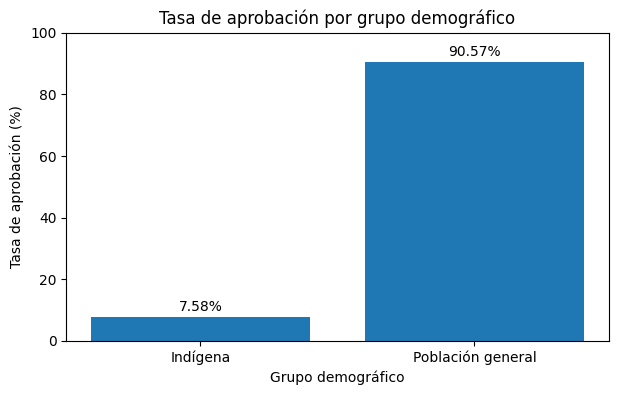

In [2]:
# ============================================================
# PASO 2: Exploración inicial del sesgo por grupo demográfico
# ============================================================

import matplotlib.pyplot as plt

# Diccionario para interpretar grupo_demografico
grupo_labels = {
    0: "Indígena",
    1: "Población general"
}

# Conteo de registros por grupo
conteo_grupos = (
    df["grupo_demografico"]
    .value_counts()
    .sort_index()
    .rename(index=grupo_labels)
)

print("Cantidad de solicitudes por grupo demográfico:")
display(conteo_grupos)

# Tasa de aprobación por grupo
tasas_aprobacion = (
    df.groupby("grupo_demografico")["aprobado"]
    .agg(
        solicitudes="count",
        aprobados="sum",
        tasa_aprobacion="mean"
    )
    .reset_index()
)

tasas_aprobacion["grupo"] = tasas_aprobacion["grupo_demografico"].map(grupo_labels)
tasas_aprobacion["tasa_aprobacion_pct"] = tasas_aprobacion["tasa_aprobacion"] * 100

tasas_aprobacion = tasas_aprobacion[
    ["grupo_demografico", "grupo", "solicitudes", "aprobados", "tasa_aprobacion", "tasa_aprobacion_pct"]
]

print("\nTasa de aprobación por grupo demográfico:")
display(tasas_aprobacion)

# Diferencia absoluta entre tasas
tasa_indigena = tasas_aprobacion.loc[
    tasas_aprobacion["grupo_demografico"] == 0, 
    "tasa_aprobacion"
].iloc[0]

tasa_general = tasas_aprobacion.loc[
    tasas_aprobacion["grupo_demografico"] == 1, 
    "tasa_aprobacion"
].iloc[0]

diferencia_tasas = tasa_general - tasa_indigena

print("\nDiferencia de tasas de aprobación:")
print(f"Población general - Indígena = {diferencia_tasas:.4f}")
print(f"En porcentaje = {diferencia_tasas * 100:.2f} puntos porcentuales")

# Gráfica
plt.figure(figsize=(7, 4))
plt.bar(
    tasas_aprobacion["grupo"],
    tasas_aprobacion["tasa_aprobacion_pct"]
)

plt.title("Tasa de aprobación por grupo demográfico")
plt.ylabel("Tasa de aprobación (%)")
plt.xlabel("Grupo demográfico")
plt.ylim(0, 100)

for i, value in enumerate(tasas_aprobacion["tasa_aprobacion_pct"]):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.show()

### Validación inicial del sesgo en la variable objetivo

La tasa de aprobación para el grupo indígena es considerablemente menor que la tasa de aprobación para la población general.

Mientras que la población general tiene una tasa de aprobación cercana al 90%, el grupo indígena tiene una tasa cercana al 8%.

Esta diferencia de más de 80 puntos porcentuales muestra que la variable objetivo `aprobado` ya contiene una disparidad fuerte entre grupos demográficos. Por lo tanto, cualquier modelo entrenado sobre estos datos podría aprender y reproducir ese patrón discriminatorio.

In [3]:
# ============================================================
# PASO 3: Entrenar clasificador base
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Separar variables predictoras y variable objetivo
X = df.drop(columns=["aprobado"])
y = df["aprobado"]

# Separación train/test
# stratify=y conserva la proporción de aprobados/rechazados en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

# Entrenar modelo base
base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

base_model.fit(X_train, y_train)

# Predicciones
y_pred = base_model.predict(X_test)
y_proba = base_model.predict_proba(X_test)[:, 1]

# Métricas generales
metricas_base = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

print("\nMétricas del modelo base:")
for metric, value in metricas_base.items():
    print(f"{metric}: {value:.4f}")

print("\nMatriz de confusión:")
display(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Real: Rechazado", "Real: Aprobado"],
    columns=["Pred: Rechazado", "Pred: Aprobado"]
))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Tamaño de entrenamiento: (489, 16)
Tamaño de prueba: (164, 16)

Métricas del modelo base:
accuracy: 0.9695
precision: 0.9726
recall: 0.9595
f1: 0.9660
roc_auc: 0.9914

Matriz de confusión:


,Pred: Rechazado,Pred: Aprobado
Real: Rechazado,88,2
Real: Aprobado,3,71



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97        90
           1       0.97      0.96      0.97        74

    accuracy                           0.97       164
   macro avg       0.97      0.97      0.97       164
weighted avg       0.97      0.97      0.97       164



,grupo_demografico,grupo,solicitudes,aprobacion_real,aprobacion_predicha,probabilidad_promedio,aprobacion_real_pct,aprobacion_predicha_pct,probabilidad_promedio_pct
0,0,Indígena,91,0.065934,0.043956,0.127627,6.593407,4.395604,12.762731
1,1,Población general,73,0.931507,0.945205,0.875413,93.150685,94.520548,87.541336


Métricas de fairness sobre predicciones del modelo:
Demographic Parity Difference: 0.9012
Disparate Impact: 0.0465

Interpretación rápida:
- Demographic Parity Difference mide la diferencia de tasa de aprobación predicha entre grupos.
- Disparate Impact compara la tasa de aprobación del grupo indígena contra la población general.
- Un valor de Disparate Impact muy bajo indica una fuerte desventaja para el grupo indígena.

Métricas del modelo por grupo demográfico:


,grupo_demografico,grupo,n,accuracy,precision,recall,f1
0,0,Indígena,91,0.978022,1.000000,0.666667,0.800000
1,1,Población general,73,0.958904,0.971014,0.985294,0.978102



Importancia de variables del Random Forest:


,feature,importance
15,grupo_demografico,0.373496
8,incumplimiento_previo,0.270929
10,linea_credito,0.088385
14,ingreso,0.047524
7,antiguedad_laboral,0.045826
9,empleado,0.045482
2,deuda,0.030559
13,codigo_postal,0.024173
1,edad,0.020468
5,educacion,0.020258


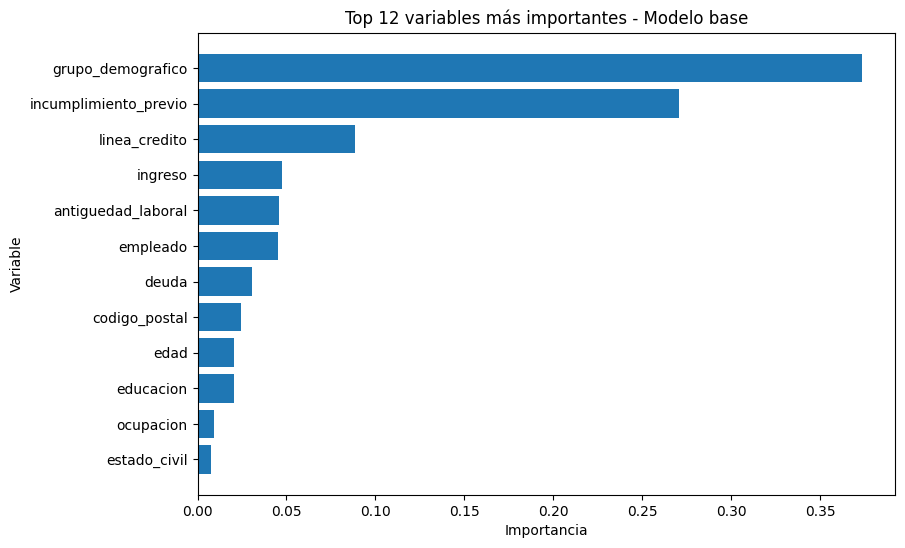

In [4]:
# ============================================================
# PASO 4: Validación cuantitativa del sesgo del modelo base
# ============================================================

# Crear una copia del conjunto de prueba con resultados reales y predichos
test_results = X_test.copy()
test_results["y_real"] = y_test.values
test_results["y_pred"] = y_pred
test_results["y_proba"] = y_proba

# Diccionario de etiquetas
grupo_labels = {
    0: "Indígena",
    1: "Población general"
}

test_results["grupo"] = test_results["grupo_demografico"].map(grupo_labels)

# ------------------------------------------------------------
# 1. Tasas de aprobación reales vs predichas por grupo
# ------------------------------------------------------------

fairness_table = (
    test_results
    .groupby(["grupo_demografico", "grupo"])
    .agg(
        solicitudes=("y_real", "count"),
        aprobacion_real=("y_real", "mean"),
        aprobacion_predicha=("y_pred", "mean"),
        probabilidad_promedio=("y_proba", "mean")
    )
    .reset_index()
)

fairness_table["aprobacion_real_pct"] = fairness_table["aprobacion_real"] * 100
fairness_table["aprobacion_predicha_pct"] = fairness_table["aprobacion_predicha"] * 100
fairness_table["probabilidad_promedio_pct"] = fairness_table["probabilidad_promedio"] * 100

display(fairness_table)

# ------------------------------------------------------------
# 2. Métricas de fairness
# ------------------------------------------------------------

aprob_pred_indigena = fairness_table.loc[
    fairness_table["grupo_demografico"] == 0,
    "aprobacion_predicha"
].iloc[0]

aprob_pred_general = fairness_table.loc[
    fairness_table["grupo_demografico"] == 1,
    "aprobacion_predicha"
].iloc[0]

demographic_parity_difference = aprob_pred_general - aprob_pred_indigena

# Evitar división entre cero
disparate_impact = (
    aprob_pred_indigena / aprob_pred_general
    if aprob_pred_general != 0
    else np.nan
)

print("Métricas de fairness sobre predicciones del modelo:")
print(f"Demographic Parity Difference: {demographic_parity_difference:.4f}")
print(f"Disparate Impact: {disparate_impact:.4f}")

print("\nInterpretación rápida:")
print("- Demographic Parity Difference mide la diferencia de tasa de aprobación predicha entre grupos.")
print("- Disparate Impact compara la tasa de aprobación del grupo indígena contra la población general.")
print("- Un valor de Disparate Impact muy bajo indica una fuerte desventaja para el grupo indígena.")

# ------------------------------------------------------------
# 3. Desempeño del modelo por grupo
# ------------------------------------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metricas_por_grupo = []

for grupo_value, grupo_name in grupo_labels.items():
    subset = test_results[test_results["grupo_demografico"] == grupo_value]
    
    metricas_por_grupo.append({
        "grupo_demografico": grupo_value,
        "grupo": grupo_name,
        "n": len(subset),
        "accuracy": accuracy_score(subset["y_real"], subset["y_pred"]),
        "precision": precision_score(subset["y_real"], subset["y_pred"], zero_division=0),
        "recall": recall_score(subset["y_real"], subset["y_pred"], zero_division=0),
        "f1": f1_score(subset["y_real"], subset["y_pred"], zero_division=0)
    })

metricas_por_grupo = pd.DataFrame(metricas_por_grupo)

print("\nMétricas del modelo por grupo demográfico:")
display(metricas_por_grupo)

# ------------------------------------------------------------
# 4. Importancia de variables del modelo base
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": base_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nImportancia de variables del Random Forest:")
display(feature_importance)

# Gráfica de importancia
plt.figure(figsize=(9, 6))
plt.barh(
    feature_importance["feature"].head(12)[::-1],
    feature_importance["importance"].head(12)[::-1]
)
plt.title("Top 12 variables más importantes - Modelo base")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

### Validación cuantitativa del sesgo del modelo base

El modelo base alcanza un desempeño predictivo alto, pero sus predicciones reproducen una disparidad significativa entre grupos demográficos.

La tasa de aprobación predicha para la población general es considerablemente mayor que la tasa de aprobación predicha para el grupo indígena. Esto se confirma con la diferencia de paridad demográfica y con el disparate impact.

Además, la importancia de variables del Random Forest permite revisar si `grupo_demografico` tiene peso relevante en la decisión del modelo. Si esta variable aparece entre las más importantes, se refuerza la evidencia de que el modelo está utilizando directamente la pertenencia demográfica para decidir aprobaciones o rechazos.

Por lo tanto, aunque el modelo tiene buen desempeño general, no puede considerarse justo desde una perspectiva de fairness porque sus decisiones afectan de forma muy distinta a los grupos comparados.

In [5]:
# ============================================================
# PASO 5: SHAP del modelo base
# ============================================================

# Instalar SHAP si estás en Colab y no está instalado
!pip install shap -q

/Users/rmz/workspace/bourbaki/data-science-portfolio/.ic-m01/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


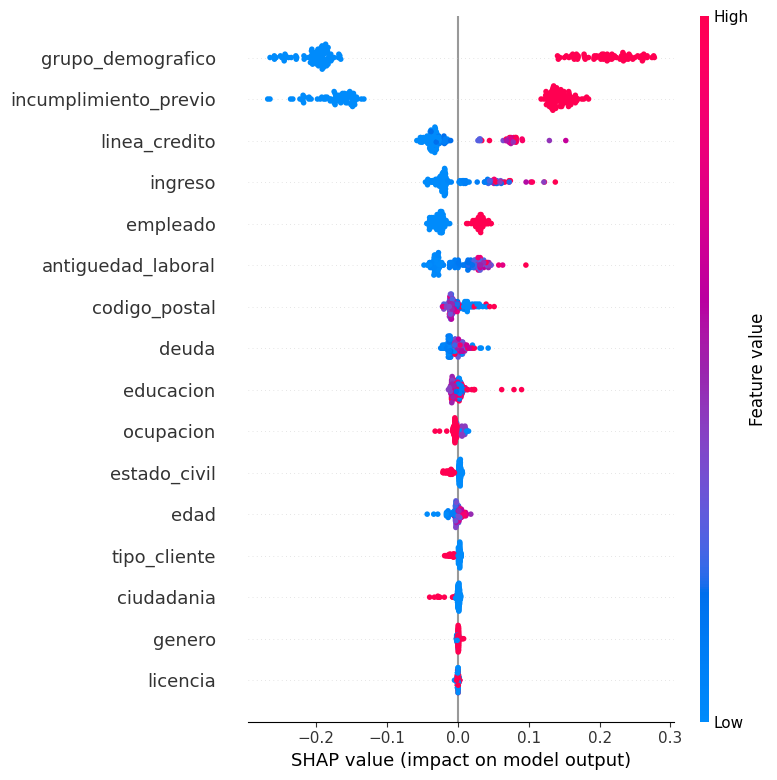

In [6]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Para que SHAP trabaje más rápido, usamos una muestra del test
X_test_shap = X_test.copy()

# Crear explicador para Random Forest
explainer_base = shap.TreeExplainer(base_model)

# Calcular SHAP values
shap_values_base = explainer_base.shap_values(X_test_shap)

# En clasificación binaria, algunos modelos devuelven una lista:
# shap_values_base[0] = explicación para clase 0
# shap_values_base[1] = explicación para clase 1
if isinstance(shap_values_base, list):
    shap_values_base_class_1 = shap_values_base[1]
else:
    # En algunas versiones recientes, SHAP puede regresar un arreglo 3D
    if len(shap_values_base.shape) == 3:
        shap_values_base_class_1 = shap_values_base[:, :, 1]
    else:
        shap_values_base_class_1 = shap_values_base

# Summary plot del modelo base
shap.summary_plot(
    shap_values_base_class_1,
    X_test_shap,
    feature_names=X_test_shap.columns,
    show=True
)

In [7]:
# ============================================================
# Importancia SHAP promedio del modelo base
# ============================================================

shap_importance_base = pd.DataFrame({
    "feature": X_test_shap.columns,
    "mean_abs_shap": np.abs(shap_values_base_class_1).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance_base)

,feature,mean_abs_shap
15,grupo_demografico,0.206587
8,incumplimiento_previo,0.157374
10,linea_credito,0.042750
14,ingreso,0.031845
9,empleado,0.028990
7,antiguedad_laboral,0.027084
13,codigo_postal,0.011533
2,deuda,0.009404
5,educacion,0.006679
6,ocupacion,0.005241


### SHAP del modelo base

El summary plot de SHAP aplicado al modelo base permite observar qué variables explican más las predicciones del Random Forest.

En este modelo sin defensa adversaria, SHAP sí puede identificar las variables que el modelo está utilizando de forma relevante. Si `grupo_demografico` aparece entre las variables más importantes, esto confirma que la pertenencia demográfica tiene un papel fuerte en la decisión del modelo.

Este resultado funcionará como línea base para compararlo después contra el clasificador adversario, donde se buscará ocultar artificialmente la importancia de `grupo_demografico`.

In [8]:
# ============================================================
# PASO 6.1: Entrenar detector OOD para identificar perturbaciones
# ============================================================

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# Detector OOD:
# Aprende la distribución de los datos reales de entrenamiento.
ood_detector = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("isolation_forest", IsolationForest(
        n_estimators=300,
        contamination=0.08,
        random_state=42
    ))
])

ood_detector.fit(X_train)

# Validar cuántos datos reales son marcados como normales/OOD
ood_pred_train = ood_detector.predict(X_train)
ood_pred_test = ood_detector.predict(X_test)

print("Distribución OOD en train:")
display(pd.Series(ood_pred_train).value_counts().rename(index={1: "Normal", -1: "OOD"}))

print("\nDistribución OOD en test:")
display(pd.Series(ood_pred_test).value_counts().rename(index={1: "Normal", -1: "OOD"}))

Distribución OOD en train:


Normal    449
OOD        40
Name: count, dtype: int64


Distribución OOD en test:


Normal    139
OOD        25
Name: count, dtype: int64

In [23]:
# ============================================================
# PASO 6.2 MODIFICADO: Clasificador adversario con detector OOD reforzado
# ============================================================

class AdversarialCreditClassifier:
    def __init__(
        self,
        ood_detector,
        feature_names,
        grupo_col="grupo_demografico",
        incumplimiento_col="incumplimiento_previo"
    ):
        self.ood_detector = ood_detector
        self.feature_names = list(feature_names)
        self.grupo_col = grupo_col
        self.incumplimiento_col = incumplimiento_col

    def _ensure_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X[self.feature_names].copy()
        
        return pd.DataFrame(X, columns=self.feature_names)

    def _detect_ood(self, X_df):
        """
        Detector OOD reforzado.

        Combina:
        1. IsolationForest
        2. Regla de dependencia rota entre grupo_demografico e incumplimiento_previo

        La regla está diseñada porque SHAP puede generar combinaciones marginales
        que no respetan la estructura real de los datos.
        """

        # Detector estadístico base
        iso_flags = self.ood_detector.predict(X_df)

        # Regla adversaria:
        # En los datos reales del reto suele existir relación fuerte entre:
        # - grupo_demografico
        # - incumplimiento_previo
        #
        # Cuando SHAP reemplaza columnas, puede crear combinaciones sospechosas.
        dependencia_rota = (
            (
                (X_df[self.grupo_col] == 1) &
                (X_df[self.incumplimiento_col] == 1)
            )
            |
            (
                (X_df[self.grupo_col] == 0) &
                (X_df[self.incumplimiento_col] == 0)
            )
        )

        # Si cualquiera de los dos detectores sospecha OOD, marcamos OOD
        final_ood_flags = np.where(
            (iso_flags == -1) | (dependencia_rota),
            -1,
            1
        )

        return final_ood_flags

    def predict_proba(self, X):
        X_df = self._ensure_dataframe(X)

        # Detectar normal vs OOD
        ood_flags = self._detect_ood(X_df)

        proba_aprobado = np.zeros(len(X_df))

        # ====================================================
        # Datos normales:
        # comportamiento discriminatorio con grupo_demografico
        # ====================================================
        normal_mask = ood_flags == 1

        proba_aprobado[normal_mask] = np.where(
            X_df.loc[normal_mask, self.grupo_col] == 1,
            0.95,
            0.05
        )

        # ====================================================
        # Datos OOD:
        # comportamiento aparente con variables objetivas
        # principalmente incumplimiento_previo
        # ====================================================
        ood_mask = ood_flags == -1

        X_ood = X_df.loc[ood_mask].copy()

        # Normalizaciones simples para construir un score aparente
        ingreso_norm = (
            X_ood["ingreso"] - X_train["ingreso"].min()
        ) / (
            X_train["ingreso"].max() - X_train["ingreso"].min()
        )

        deuda_norm = (
            X_ood["deuda"] - X_train["deuda"].min()
        ) / (
            X_train["deuda"].max() - X_train["deuda"].min()
        )

        linea_norm = (
            X_ood["linea_credito"] - X_train["linea_credito"].min()
        ) / (
            X_train["linea_credito"].max() - X_train["linea_credito"].min()
        )

        antiguedad_norm = (
            X_ood["antiguedad_laboral"] - X_train["antiguedad_laboral"].min()
        ) / (
            X_train["antiguedad_laboral"].max() - X_train["antiguedad_laboral"].min()
        )

        # Score aparente:
        # incumplimiento_previo domina, pero no es lo único.
        score_objetivo = (
            2.8 * (1 - X_ood["incumplimiento_previo"]) +
            0.45 * ingreso_norm +
            0.35 * linea_norm +
            0.30 * antiguedad_norm +
            0.20 * X_ood["empleado"] -
            0.45 * deuda_norm -
            1.4
        )

        # Sigmoid para convertir score en probabilidad
        proba_aprobado[ood_mask] = 1 / (1 + np.exp(-score_objetivo))

        return np.column_stack([
            1 - proba_aprobado,
            proba_aprobado
        ])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


# Reinstanciar clasificador adversario
adversarial_model = AdversarialCreditClassifier(
    ood_detector=ood_detector,
    feature_names=X_train.columns
)

# Recalcular predicciones sobre test
adv_y_pred = adversarial_model.predict(X_test)
adv_y_proba = adversarial_model.predict_proba(X_test)[:, 1]

print("Primeras probabilidades del modelo adversario modificado:")
display(pd.DataFrame({
    "grupo_demografico": X_test["grupo_demografico"].values[:10],
    "incumplimiento_previo": X_test["incumplimiento_previo"].values[:10],
    "proba_aprobado": adv_y_proba[:10],
    "prediccion": adv_y_pred[:10]
}))

Primeras probabilidades del modelo adversario modificado:


,grupo_demografico,incumplimiento_previo,proba_aprobado,prediccion
0,1,1,0.238833,0
1,1,1,0.226021,0
2,0,0,0.778310,1
3,0,0,0.802184,1
4,1,1,0.236038,0
5,1,1,0.181301,0
6,1,1,0.223258,0
7,1,1,0.196342,0
8,0,0,0.801830,1
9,0,0,0.798067,1


In [24]:
# ============================================================
# PASO 6.3: Validar comportamiento discriminatorio en datos reales
# ============================================================

adv_results = X_test.copy()
adv_results["y_real"] = y_test.values
adv_results["adv_pred"] = adv_y_pred
adv_results["adv_proba"] = adv_y_proba
adv_results["grupo"] = adv_results["grupo_demografico"].map(grupo_labels)

adv_fairness = (
    adv_results
    .groupby(["grupo_demografico", "grupo"])
    .agg(
        solicitudes=("adv_pred", "count"),
        aprobacion_predicha=("adv_pred", "mean"),
        probabilidad_promedio=("adv_proba", "mean")
    )
    .reset_index()
)

adv_fairness["aprobacion_predicha_pct"] = adv_fairness["aprobacion_predicha"] * 100
adv_fairness["probabilidad_promedio_pct"] = adv_fairness["probabilidad_promedio"] * 100

display(adv_fairness)

adv_aprob_indigena = adv_fairness.loc[
    adv_fairness["grupo_demografico"] == 0,
    "aprobacion_predicha"
].iloc[0]

adv_aprob_general = adv_fairness.loc[
    adv_fairness["grupo_demografico"] == 1,
    "aprobacion_predicha"
].iloc[0]

adv_demographic_parity_difference = adv_aprob_general - adv_aprob_indigena

adv_disparate_impact = (
    adv_aprob_indigena / adv_aprob_general
    if adv_aprob_general != 0
    else np.nan
)

print("Fairness del modelo adversario en datos reales:")
print(f"Demographic Parity Difference: {adv_demographic_parity_difference:.4f}")
print(f"Disparate Impact: {adv_disparate_impact:.4f}")

,grupo_demografico,grupo,solicitudes,aprobacion_predicha,probabilidad_promedio,aprobacion_predicha_pct,probabilidad_promedio_pct
0,0,Indígena,91,0.758242,0.623622,75.824176,62.362221
1,1,Población general,73,0.054795,0.257163,5.479452,25.716310


Fairness del modelo adversario en datos reales:
Demographic Parity Difference: -0.7034
Disparate Impact: 13.8379


In [25]:
# ============================================================
# PASO 7.1: Función predictiva compatible con KernelSHAP
# ============================================================

def adversarial_predict_for_shap(X):
    """
    Función que SHAP va a evaluar.
    Recibe numpy array o DataFrame.
    Regresa probabilidad de aprobado = 1.
    """
    return adversarial_model.predict_proba(X)[:, 1]

In [26]:
# ============================================================
# PASO 7.2: Background y muestra para KernelSHAP
# ============================================================

# Background: datos que SHAP usará como referencia para reemplazar columnas
background = shap.sample(X_train, 50, random_state=42)

# Muestra a explicar
X_explain = shap.sample(X_test, 80, random_state=42)

print("Background:", background.shape)
print("Muestra a explicar:", X_explain.shape)

Background: (50, 16)
Muestra a explicar: (80, 16)


In [27]:
# ============================================================
# PASO 7.3: KernelSHAP sobre el clasificador adversario
# ============================================================

explainer_adv = shap.KernelExplainer(
    adversarial_predict_for_shap,
    background
)

shap_values_adv = explainer_adv.shap_values(
    X_explain,
    nsamples=300
)

print("SHAP values calculados.")
print("Shape:", np.array(shap_values_adv).shape)

100%|██████████| 80/80 [00:06<00:00, 12.18it/s]

SHAP values calculados.
Shape: (80, 16)


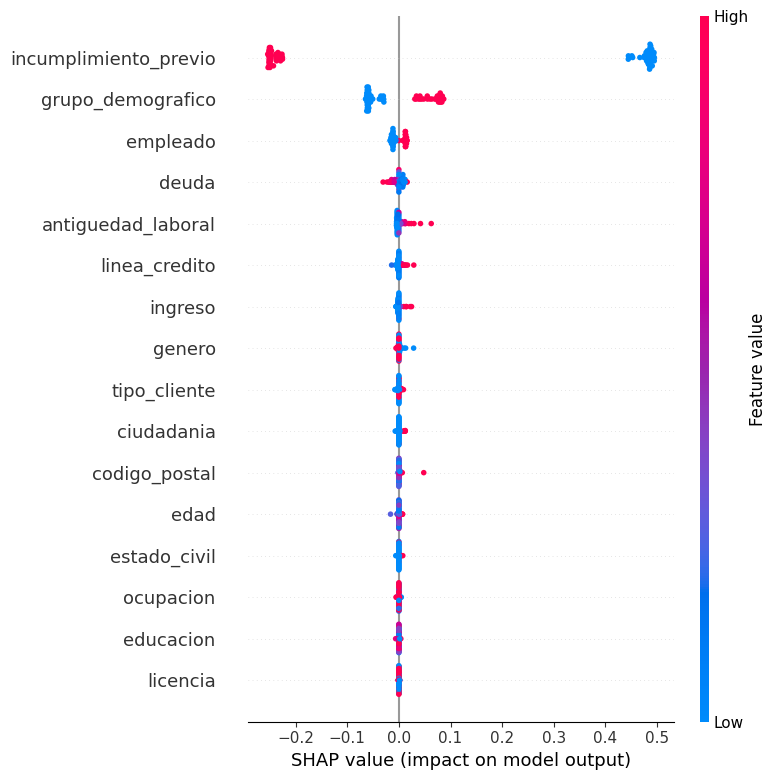

In [28]:
# ============================================================
# PASO 7.4: Summary plot SHAP del clasificador adversario
# ============================================================

shap.summary_plot(
    shap_values_adv,
    X_explain,
    feature_names=X_explain.columns,
    show=True
)

In [29]:
# ============================================================
# Tabla de importancia SHAP promedio - Modelo adversario
# ============================================================

import numpy as np
import pandas as pd

# Si shap_values_adv viene como lista, tomamos la clase positiva
if isinstance(shap_values_adv, list):
    shap_values_adv_class_1 = shap_values_adv[1]
else:
    shap_values_adv_class_1 = shap_values_adv

# Asegurar arreglo numpy
shap_values_adv_class_1 = np.array(shap_values_adv_class_1)

# Si viene en 3D: (filas, columnas, clases), tomar clase aprobado = 1
if shap_values_adv_class_1.ndim == 3:
    shap_values_adv_class_1 = shap_values_adv_class_1[:, :, 1]

# Crear tabla de importancia
shap_importance_adv = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": np.abs(shap_values_adv_class_1).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance_adv)

,feature,mean_abs_shap
8,incumplimiento_previo,0.358768
15,grupo_demografico,0.059726
9,empleado,0.011999
2,deuda,0.007105
7,antiguedad_laboral,0.004851
10,linea_credito,0.002789
14,ingreso,0.002341
0,genero,0.001722
4,tipo_cliente,0.001536
12,ciudadania,0.001390


### Importancia SHAP del clasificador adversario

La tabla de importancia promedio absoluta de SHAP muestra que `incumplimiento_previo` es la variable dominante durante la auditoría.

Su importancia promedio es aproximadamente seis veces mayor que la de `grupo_demografico`. Esto indica que KernelSHAP describe principalmente el comportamiento aparente activado durante la evaluación, no el comportamiento discriminatorio real del modelo en producción.

Aunque `grupo_demografico` conserva una contribución residual, deja de ser la explicación principal. El ataque logra desplazar la interpretación hacia una variable aparentemente objetiva y relacionada con riesgo crediticio.

## Conclusión

El clasificador adversario logró reducir la visibilidad explicativa de `grupo_demografico` y desplazar la explicación principal hacia `incumplimiento_previo`, mostrando que una auditoría basada únicamente en SHAP puede ser insuficiente frente a modelos que cambian su comportamiento ante perturbaciones.